# 02 — Dynamic Pricing Model
XGBoost surge prediction + MLflow tracking

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error
import mlflow, mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

In [21]:
df = pd.read_csv('sample_rides.csv', parse_dates=['timestamp'])
le = LabelEncoder()
df['zone_enc'] = le.fit_transform(df['zone'])

FEATURES = ['demand_supply_ratio','demand_score','supply_score',
            'hour','weekday','is_weekend','zone_enc']
TARGET = 'surge_multiplier'

X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (800, 7) | Test: (200, 7)


## Baseline

In [22]:
baseline = mean_absolute_error(y_test, np.full(len(y_test), y_train.median()))
print(f'Baseline MAE (median): {baseline:.4f}')

Baseline MAE (median): 0.0170


## Train XGBoost + MLflow

In [26]:
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)

In [27]:
mlflow.set_tracking_uri("file:///ML workflow/marketplace-pricing-ml/mlruns")
params = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8, random_state=42)

with mlflow.start_run(run_name='xgb_v1'):
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    preds_tr = model.predict(X_train)
    preds_te = model.predict(X_test)
    metrics = {
        'train_mae': mean_absolute_error(y_train, preds_tr),
        'test_mae' : mean_absolute_error(y_test,  preds_te),
        'test_rmse': mean_squared_error(y_test, preds_te),
        'test_r2'  : r2_score(y_test, preds_te),
    }
    mlflow.log_params(params)
    [mlflow.log_metric(k, v) for k, v in metrics.items()]
    mlflow.sklearn.log_model(model, name='pricing_model')
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}')
print(f'  improvement over baseline: {baseline - metrics["test_mae"]:.4f}')

  train_mae: 0.0113
  test_mae: 0.0195
  test_rmse: 0.0006
  test_r2: -0.0895
  improvement over baseline: -0.0025


## Predictions vs actuals

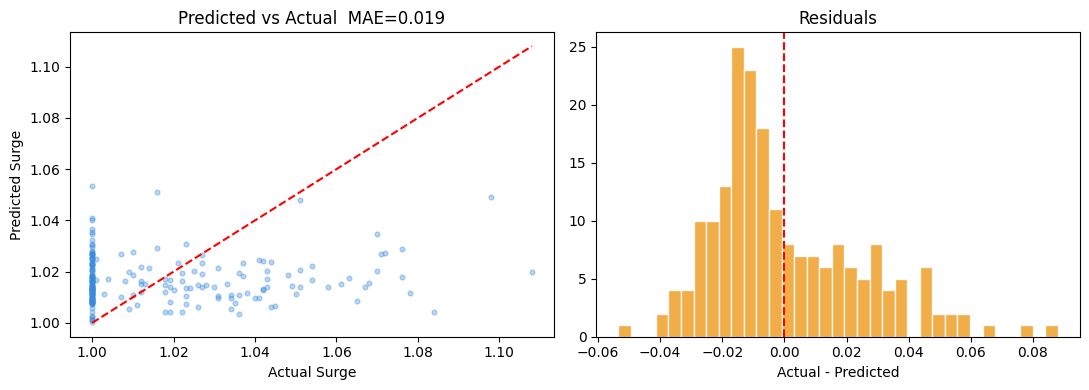

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, preds_te, alpha=0.35, s=12, color='#378ADD')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx], 'r--', lw=1.5)
axes[0].set(title=f'Predicted vs Actual  MAE={metrics["test_mae"]:.3f}',
            xlabel='Actual Surge', ylabel='Predicted Surge')
axes[1].hist(y_test.values - preds_te, bins=35, color='#EF9F27', alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set(title='Residuals', xlabel='Actual - Predicted')
plt.tight_layout()
plt.show()

## Feature importance

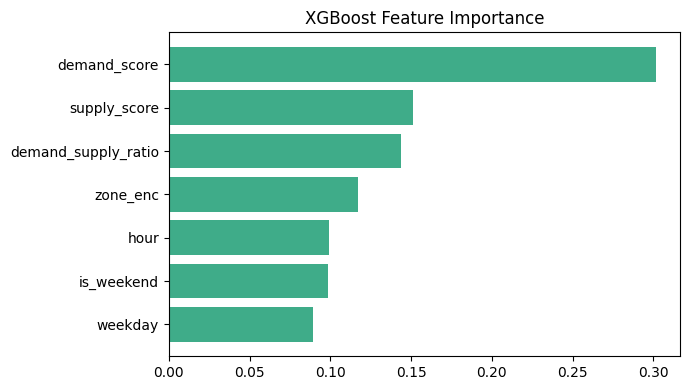

In [29]:
imp = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_}
                  ).sort_values('importance')
plt.figure(figsize=(7, 4))
plt.barh(imp['feature'], imp['importance'], color='#1D9E75', alpha=0.85)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## Real-time scoring

In [30]:
scenarios = pd.DataFrame([
    {'demand_supply_ratio':2.8,'demand_score':5.5,'supply_score':2.0,
     'hour':18,'weekday':4,'is_weekend':0,'zone_enc':0, 'label':'Fri 6pm peak'},
    {'demand_supply_ratio':0.7,'demand_score':1.2,'supply_score':4.5,
     'hour':14,'weekday':2,'is_weekend':0,'zone_enc':3, 'label':'Wed 2pm quiet'},
    {'demand_supply_ratio':2.0,'demand_score':4.2,'supply_score':2.5,
     'hour':1, 'weekday':5,'is_weekend':1,'zone_enc':1, 'label':'Sat 1am night out'},
])
preds_s = model.predict(scenarios[FEATURES])
base = 7.0
for i, row in scenarios.iterrows():
    print(f"{row['label']}")
    print(f"  surge: {preds_s[i]:.2f}x  price: EUR {base*preds_s[i]:.2f}")
    print()

Fri 6pm peak
  surge: 1.19x  price: EUR 8.32

Wed 2pm quiet
  surge: 1.01x  price: EUR 7.06

Sat 1am night out
  surge: 1.06x  price: EUR 7.43

